# 6CS012 – Worksheet 5
## End-to-End CNN Model for Image Classification


## Installs & Imports

In [1]:
!pip install tensorflow scikit-learn matplotlib pillow -q

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Mount Google Drive & Set Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)
print(f'Classes found : {class_names}')
print(f'Number of classes: {num_classes}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes found : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


## Task 1a - Visualise One Image Per Class

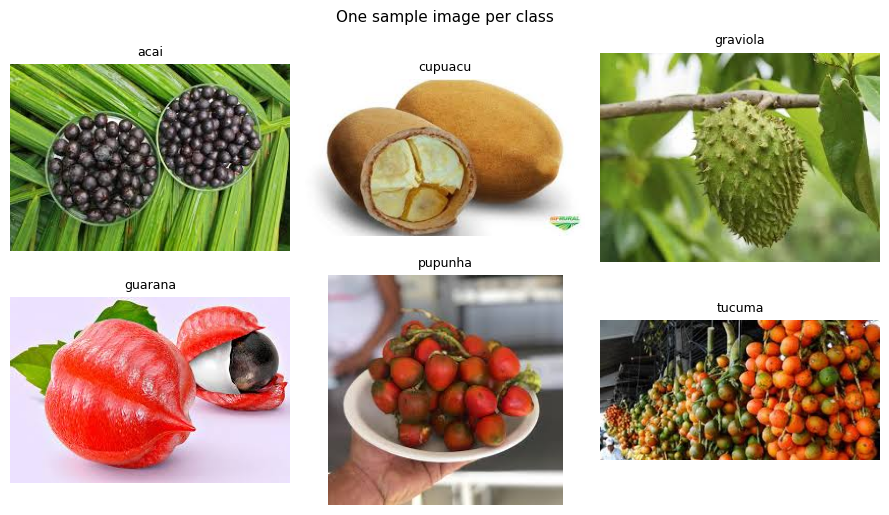

In [6]:
cols = 3
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.5))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(cls_path, random.choice(images))
    img      = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('One sample image per class', y=1.02, fontsize=11)
plt.show()

**Observation:**
The dataset has 6 fruit classes. Each fruit looks quite different from one another in terms of colour
and shape which should help the model tell them apart. However some images have busy backgrounds
and the same fruit can look different depending on the angle or whether it is whole or cut open.
The images also vary in size and resolution which is why we resize them all to 128x128 before
training.

## Task 1b - Detect & Remove Corrupted Images

In [7]:
corrupted = []

for cls in class_names:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()   # detects truncated / corrupt files
        except (IOError, SyntaxError):
            print(f'Removed corrupted image: {img_path}')
            os.remove(img_path)
            corrupted.append(img_path)

if not corrupted:
    print('No corrupted images found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted)}')

No corrupted images found.


## Task 2 - Load & Preprocess Image Data

In [9]:
img_height       = 128
img_width        = 128
batch_size       = 16
validation_split = 0.2
seed             = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = batch_size,
    shuffle       = False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f'class names: {class_names}')
print(f'num classes: {num_classes}')

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
num classes: 6


In [10]:
# Normalise pixel values to [0, 1]
rescale = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

print('Datasets ready.')

Datasets ready.


## Task 3 - Build the CNN Model

In [12]:
model = keras.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = 1,
        padding     = 'same',
        activation  = 'relu',
        input_shape = (img_height, img_width, 3)
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = 1,
        padding     = 'same',
        activation  = 'relu'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')

], name='fruits_cnn')

model.summary()

Model: "fruits_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 - Compile the Model

In [13]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print('Model compiled.')

Model compiled.


## Task 4 - Train the Model (250 epochs with callbacks)

In [14]:
CHECKPOINT_PATH = 'best_model.h5'

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 20,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath          = CHECKPOINT_PATH,
        monitor           = 'val_accuracy',
        save_best_only    = True,
        save_weights_only = False,
        verbose           = 1
    )
]

history = model.fit(
    train_ds,
    epochs          = 250,
    validation_data = val_ds,
    callbacks       = callbacks
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.1955 - loss: 2.0934
Epoch 1: val_accuracy improved from None to 0.66667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 481ms/step - accuracy: 0.1806 - loss: 2.0496 - val_accuracy: 0.6667 - val_loss: 1.4792
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3597 - loss: 1.7596
Epoch 2: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.3611 - loss: 1.7034 - val_accuracy: 0.1667 - val_loss: 1.5639
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.4632 - loss: 1.5296
Epoch 3: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 0.4722 - loss: 1.4465 - val_accuracy: 0.5556 - val_loss: 1.3470
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5875 - loss: 1.1933
Epoch 4: val_accuracy improved from 0.66667 to 0.72222, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step - accuracy: 0.6250 - loss: 1.0842 - val_accuracy: 0.7222 - val_loss: 0.9857
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.6889 - loss: 0.8849
Epoch 5: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.7778 - loss: 0.7364 - val_accuracy: 0.7222 - val_loss: 0.8306
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8938 - loss: 0.4732
Epoch 6: val_accuracy improved from 0.72222 to 0.88889, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.9167 - loss: 0.3972 - val_accuracy: 0.8889 - val_loss: 0.5052
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9712 - loss: 0.2324
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 521ms/step - accuracy: 0.9861 - loss: 0.1785 - val_accuracy: 0.8333 - val_loss: 0.6010
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 1.0000 - loss: 0.0894
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 525ms/step - accuracy: 1.0000 - loss: 0.0797 - val_accuracy: 0.8889 - val_loss: 0.4878
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9736 - loss: 0.0777
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.9722 - loss: 0.0650 - val_accuracy: 0.6111 - val_loss: 1.6055
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9385 - loss: 0.14

## Task 5a - Plot Training & Validation Curves

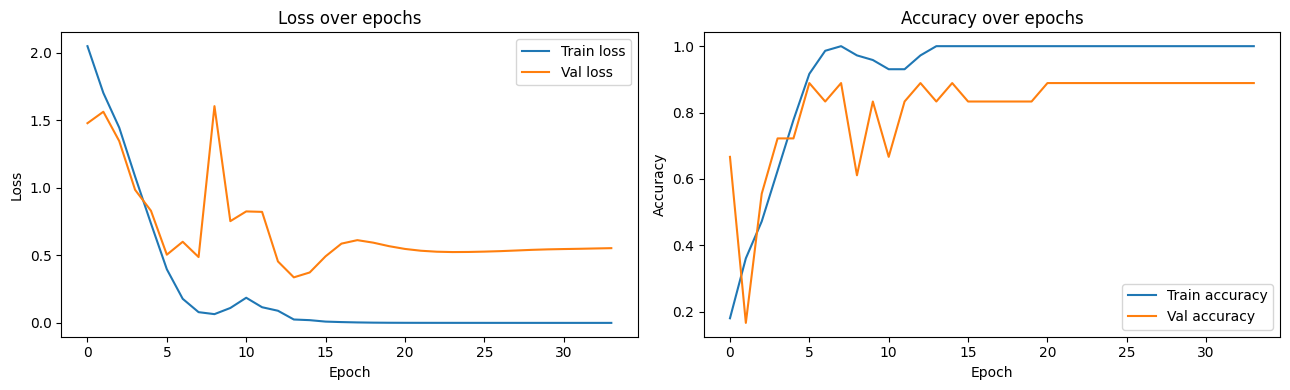

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss
ax1.plot(history.history['loss'],     label='Train loss')
ax1.plot(history.history['val_loss'], label='Val loss')
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(history.history['accuracy'],     label='Train accuracy')
ax2.plot(history.history['val_accuracy'], label='Val accuracy')
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## Task 5b - Evaluate on Test Set

In [16]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5667 - loss: 1.0549

Test loss     : 1.0549
Test accuracy : 0.5667


## Task 6 - Save & Reload the Model

In [18]:
# Save final model
model.save('fruits_cnn_final.h5')
print('Model saved as fruits_cnn_final.h5')

# Reload
loaded_model = keras.models.load_model('fruits_cnn_final.h5')
print('Model loaded successfully.')

# Re-evaluate with loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f'\nLoaded model – test loss     : {loaded_loss:.4f}')
print(f'Loaded model – test accuracy : {loaded_acc:.4f}')

Model saved as fruits_cnn_final.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.5667 - loss: 1.0549

Loaded model – test loss     : 1.0549
Loaded model – test accuracy : 0.5667


## Task 7 - Predictions & Classification Report

In [19]:
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.56      1.00      0.71         5
    graviola       1.00      0.20      0.33         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.57      0.80      0.67         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.57        30
   macro avg       0.63      0.57      0.51        30
weighted avg       0.63      0.57      0.51        30

